# 01 · Studi Baseline *Vanilla* (Zero-shot COCO)

**Alur:** data → baseline vanilla → evaluasi → figur.

Mengukur kemampuan model **pretrained COCO apa adanya** (tanpa fine-tuning) pada
test set deteksi helm (3 kelas: `helmet`, `license_plate`, `motorcyclist`).
Membandingkan arsitektur **YOLOv8s vs YOLO11s** sebagai titik nol sebelum fine-tuning.

## Metodologi (opsi B — laporkan mAP 3-kelas penuh)

Bobot COCO mengenal 80 kelas yang **tidak memuat** `helmet` maupun `license_plate`.
Maka secara desain:

| Kelas kita | Padanan COCO | Konsekuensi |
|---|---|---|
| `helmet` | — (tak ada) | AP ≈ **0** |
| `license_plate` | — (tak ada) | AP ≈ **0** |
| `motorcyclist` | `motorcycle` (id 3) | dipetakan & dievaluasi |

> **Pemetaan yang dipilih:** `COCO motorcycle(3) → motorcyclist`. Alternatif yang
> defensible adalah `COCO person(0) → motorcyclist`; ubah `COCO_TO_OURS` di bawah bila
> ingin memakai padanan rider. `helmet`/`license_plate` sengaja dibiarkan 0 untuk
> menonjolkan **gap domain** COCO→helm, yang justru memotivasi tahap fine-tuning.

Metrik dihitung dengan **`pycocotools`** (standar emas COCO): mAP@0.5 dan mAP@[.5:.95].

In [1]:
# === Setup: lingkungan, seed, util (pure-notebook: self-contained, tanpa src/) ===
from __future__ import annotations
import os, gc, json, random, sys, platform
from pathlib import Path

import numpy as np
import torch
import yaml

# Lokasi repo: telusuri ke atas dari cwd sampai menemukan requirements.txt
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "requirements.txt").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

DATA_YAML = REPO_ROOT / "data" / "helmet-roboflow" / "data.yaml"
TEST_IMG_DIR = REPO_ROOT / "data" / "helmet-roboflow" / "test" / "images"
TEST_LBL_DIR = REPO_ROOT / "data" / "helmet-roboflow" / "test" / "labels"
EXP = REPO_ROOT / "experiments"
FIG = REPO_ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
CLASS_NAMES = ["helmet", "license_plate", "motorcyclist"]


def set_seed(seed: int = 42, deterministic: bool = True) -> int:
    """Patok seed untuk random/numpy/torch (reproducibility)."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    return seed


def clear_gpu() -> None:
    """Bersihkan cache GPU antar-run agar tak ada memori sisa (hindari redundant)."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def collect_env() -> dict:
    info = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "cuda": torch.version.cuda,
        "cuda_available": torch.cuda.is_available(),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
    try:
        import ultralytics
        info["ultralytics"] = ultralytics.__version__
    except ImportError:
        info["ultralytics"] = None
    return info


def save_metrics(metrics: dict, run_dir: Path) -> dict:
    """Tulis metrik ke metrics.json + metrics.csv di folder run (satu sumber kebenaran)."""
    import pandas as pd
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)
    (run_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))
    pd.DataFrame([metrics]).to_csv(run_dir / "metrics.csv", index=False)
    return metrics


print("REPO_ROOT :", REPO_ROOT)
print("ENV       :", json.dumps(collect_env(), indent=2))
assert DATA_YAML.exists(), f"data.yaml tidak ditemukan: {DATA_YAML}"


REPO_ROOT : /home/bdo/code/jupyter-code/foldersr/work/project-cv
ENV       : {
  "python": "3.12.13",
  "platform": "Linux-6.8.0-124-generic-x86_64-with-glibc2.35",
  "torch": "2.8.0+cu128",
  "cuda": "12.8",
  "cuda_available": true,
  "gpu": "NVIDIA GeForce RTX 4090",
  "ultralytics": "8.4.65"
}


## Validasi data uji

In [2]:
# Hitung gambar & cek label test split
imgs = sorted(p for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp"})
cfg = yaml.safe_load(DATA_YAML.read_text())
print("Kelas    :", cfg.get("names"))
print("Test imgs:", len(imgs))
print("Test lbls:", len(list(TEST_LBL_DIR.glob("*.txt"))))

Kelas    : ['helmet', 'license_plate', 'motorcyclist']
Test imgs: 100
Test lbls: 100


## Evaluasi zero-shot (pycocotools)

In [3]:
# === Evaluasi zero-shot via pycocotools (opsi B) ===
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from ultralytics import YOLO

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
# Pemetaan prediksi COCO -> skema kita. helmet/license_plate tak punya padanan.
COCO_TO_OURS = {3: 2}  # motorcycle -> motorcyclist  (alt: {0: 2} utk person)
IMGSZ = 1280
CONF = 0.001  # ambang rendah untuk kurva presisi-recall COCO yang benar


def build_coco_gt(img_dir: Path, lbl_dir: Path):
    """Bangun ground-truth format COCO dari label YOLO (kelas 0,1,2)."""
    images, annotations = [], []
    categories = [{"id": i, "name": n} for i, n in enumerate(CLASS_NAMES)]
    ann_id = 1
    img_paths = sorted(p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS)
    for img_id, p in enumerate(img_paths):
        w, h = Image.open(p).size
        images.append({"id": img_id, "file_name": p.name, "width": w, "height": h})
        lbl = lbl_dir / f"{p.stem}.txt"
        if lbl.exists():
            for line in lbl.read_text().splitlines():
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x = (xc - bw / 2) * w
                y = (yc - bh / 2) * h
                annotations.append({
                    "id": ann_id, "image_id": img_id, "category_id": cls,
                    "bbox": [x, y, bw * w, bh * h], "area": bw * w * bh * h, "iscrowd": 0,
                })
                ann_id += 1
    return {"images": images, "annotations": annotations, "categories": categories}, img_paths


def coco_from_dict(d: dict) -> COCO:
    c = COCO()
    c.dataset = d
    c.createIndex()
    return c


def predict_to_coco(model, img_paths) -> list:
    dets = []
    for img_id, p in enumerate(img_paths):
        r = model.predict(str(p), imgsz=IMGSZ, conf=CONF, verbose=False, device=0)[0]
        for b in r.boxes:
            c = int(b.cls)
            if c not in COCO_TO_OURS:
                continue
            x1, y1, x2, y2 = (float(v) for v in b.xyxy[0])
            dets.append({"image_id": img_id, "category_id": COCO_TO_OURS[c],
                         "bbox": [x1, y1, x2 - x1, y2 - y1], "score": float(b.conf)})
    return dets


def evaluate_vanilla(weights: str):
    gt_dict, img_paths = build_coco_gt(TEST_IMG_DIR, TEST_LBL_DIR)
    coco_gt = coco_from_dict(gt_dict)
    model = YOLO(weights)
    dets = predict_to_coco(model, img_paths)
    del model
    clear_gpu()

    if not dets:
        per_class = {n: 0.0 for n in CLASS_NAMES}
        return {"mAP50": 0.0, "mAP50_95": 0.0, "per_class_AP50": per_class}

    coco_dt = coco_gt.loadRes(dets)
    E = COCOeval(coco_gt, coco_dt, iouType="bbox")
    E.evaluate(); E.accumulate(); E.summarize()
    prec = E.eval["precision"]  # [T, R, K, A, M]; T=0 -> IoU 0.5
    per_class = {}
    for k, n in enumerate(CLASS_NAMES):
        p = prec[0, :, k, 0, -1]
        p = p[p > -1]
        per_class[n] = float(p.mean()) if p.size else 0.0
    return {"mAP50": float(E.stats[1]), "mAP50_95": float(E.stats[0]),
            "per_class_AP50": per_class}

In [4]:
# === Jalankan eval vanilla untuk kedua arsitektur (berurutan) ===
VANILLA = {
    "YOLOv8s (vanilla)": str(EXP / "yolov8s.pt"),
    "YOLO11s (vanilla)": str(EXP / "yolo11s.pt"),
}
RUN_DIR = {"YOLOv8s (vanilla)": "vanilla_yolov8s", "YOLO11s (vanilla)": "vanilla_yolo11s"}

vanilla_results = {}
for name, w in VANILLA.items():
    print(f"\n=== Zero-shot eval: {name} ({w}) ===")
    res = evaluate_vanilla(w)
    flat = {"mAP50": res["mAP50"], "mAP50_95": res["mAP50_95"],
            **{f"AP50_{k}": v for k, v in res["per_class_AP50"].items()}}
    save_metrics(flat, EXP / RUN_DIR[name])
    vanilla_results[name] = res
    print(json.dumps(res, indent=2))
    clear_gpu()


=== Zero-shot eval: YOLOv8s (vanilla) (/home/bdo/code/jupyter-code/foldersr/work/project-cv/experiments/yolov8s.pt) ===
creating index...
index created!


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.099
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.008
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.024
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.013
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.035
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.036
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.101
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.116
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10


=== Zero-shot eval: YOLO11s (vanilla) (/home/bdo/code/jupyter-code/foldersr/work/project-cv/experiments/yolo11s.pt) ===
creating index...
index created!


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.009
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.039
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.039
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.093
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

## Figur

,Model,mAP@0.5,mAP@[.5:.95],AP50·helmet,AP50·license_plate,AP50·motorcyclist
0,YOLOv8s (vanilla),0.0986,0.0270,0.0000,0.0000,0.2957
1,YOLO11s (vanilla),0.1143,0.0320,0.0000,0.0000,0.3429


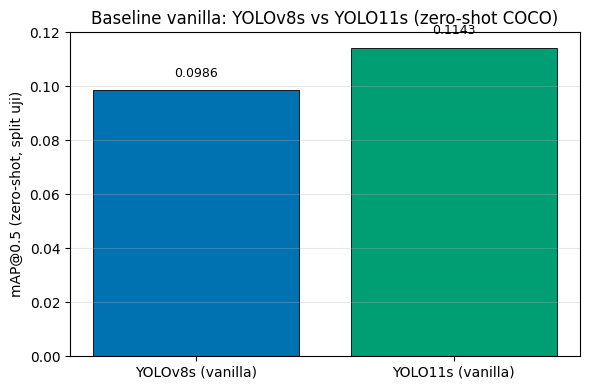

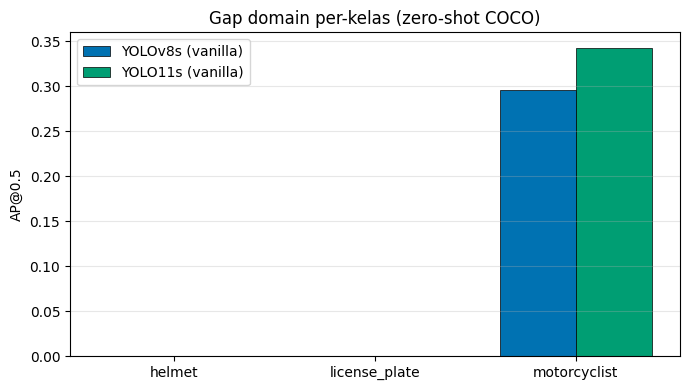

Figur tersimpan di /home/bdo/code/jupyter-code/foldersr/work/project-cv/results/figures


In [5]:
# === Figur: perbandingan vanilla & gap per-kelas ===
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

# Tabel ringkas
rows = [{"Model": n, "mAP@0.5": r["mAP50"], "mAP@[.5:.95]": r["mAP50_95"],
         **{f"AP50·{k}": v for k, v in r["per_class_AP50"].items()}}
        for n, r in vanilla_results.items()]
df = pd.DataFrame(rows)
display(df.style.format({c: "{:.4f}" for c in df.columns if c != "Model"}))

C = {"YOLOv8s (vanilla)": "#0072B2", "YOLO11s (vanilla)": "#009E73"}

# Fig: mAP@0.5 vanilla v8 vs v11
fig, ax = plt.subplots(figsize=(6, 4))
names = list(vanilla_results)
vals = [vanilla_results[n]["mAP50"] for n in names]
ax.bar(names, vals, color=[C[n] for n in names], edgecolor="black", linewidth=0.6)
ax.set_ylabel("mAP@0.5 (zero-shot, split uji)")
ax.set_title("Baseline vanilla: YOLOv8s vs YOLO11s (zero-shot COCO)")
for i, v in enumerate(vals):
    ax.text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(FIG / "vanilla_mAP50.png", dpi=300); plt.show()

# Fig: AP per-kelas (menonjolkan helmet/plate -> 0)
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(CLASS_NAMES)); w = 0.38
for i, n in enumerate(names):
    pc = vanilla_results[n]["per_class_AP50"]
    ax.bar(x + (i - 0.5) * w, [pc[c] for c in CLASS_NAMES], w,
           label=n, color=C[n], edgecolor="black", linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("AP@0.5"); ax.set_title("Gap domain per-kelas (zero-shot COCO)")
ax.legend(); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(FIG / "vanilla_per_class.png", dpi=300); plt.show()
print("Figur tersimpan di", FIG)

## Kesimpulan (isi setelah eksekusi)

- `helmet` & `license_plate` mendekati **0** pada kedua model — bobot COCO tidak
  mengenal kelas ini → **gap domain besar**, motivasi kuat untuk fine-tuning.
- Bandingkan `motorcyclist` antar YOLOv8s vs YOLO11s untuk kemampuan lokalisasi
  bawaan (lewat padanan `motorcycle`).
- Angka aktual ada di tabel & `experiments/vanilla_*/metrics.json`.

> Lanjut ke **02a/02b/02c** untuk fine-tuning, lalu **03** untuk studi komparatif.